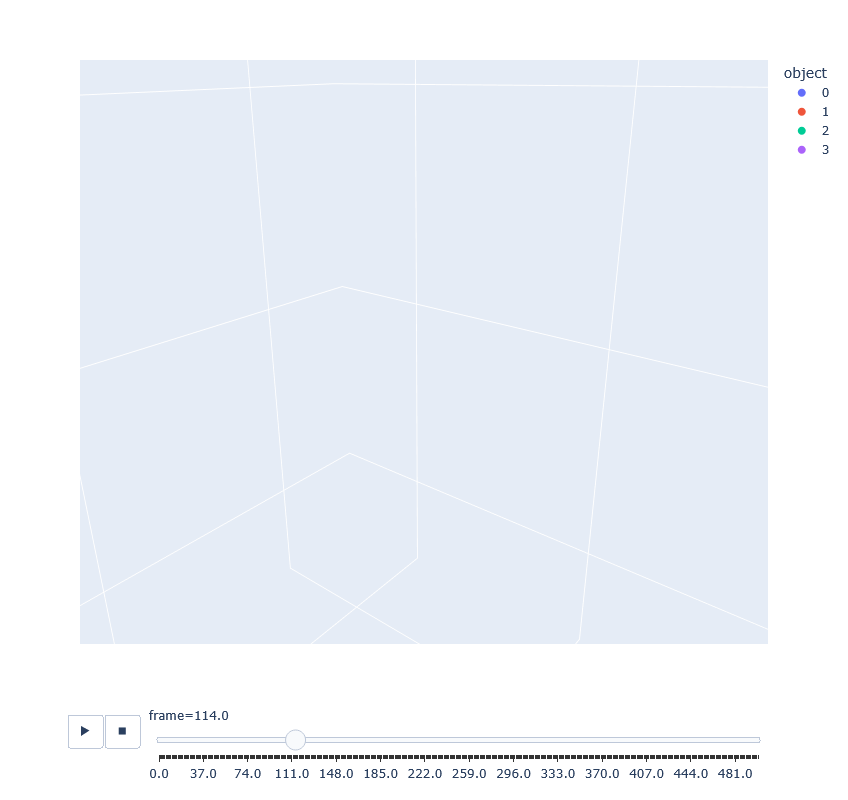

In [2]:
import numpy as np
import plotly.express as px
import pandas as pd

N = 4 #Number of objects
Time = 250 #Duration of the simulation
frame_skip = 50 #Number of timesteps between frames

M = 50 #Mass Multiploer [M=1, objects will have a mass between 0 and 1]
R = 100 #Intital Postition Multiplier [R=1, objects will be randomly placed in a 1x1x1 cube]
vm = 1.5 #Velocity Multiplier [vm=1, objects will have a velocity between 0 and 1 in each direction]
soft_len = 0.1 #Softening Length to prevent singularities in force calculations when objects get very close to each other
G = 1 #Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)

dt = 0.01 #Timestep
t = 0 #Intializing time
frames = [] #Setting the empty frame list
frame_num = 0 #Intializing frame number

#Setting array of objects: 
    #col 0,1,2 stores position in x,y,z directions
    #col 3 stores mass
    #col 4,5,6 stores momentum in x,y,z directions
    #col 7,8,9 stores force on the object in x,y,z directions
objects = np.zeros([N,10])

#Gives objects a random initial position, mass, and momentum
for i in range(N):
    objects[i,0:3] = R * np.array((np.random.random(),np.random.random(),np.random.random()))
    objects[i,3] = M * (1 - np.random.random()) #(1-random.random()) since random.random() returns values on the interval [0.0, 1.0)
    objects[0,3] = 1000 #Setting the first object to have a much larger mass than the others to create a more interesting simulation
    objects[i,4:7] = vm * objects[i,3] * np.array((np.random.random(),np.random.random(),np.random.random()))

#Main simulation loop
while t<Time:
    #Sets force equal to 0
    objects[:,7:10] = 0
    
    #Records current object position and frame
    if frame_num % frame_skip == 0:
        for i in range(N):
            frames.append((objects[i,0], objects[i,1], objects[i,2], str(i), frame_num/frame_skip))
    
    #Calculating the force between every object
    for i in range(N):
        for j in range(i+1,N):
            if i != j:
                r = objects[j,0:3] - objects[i,0:3]
                r_dot = np.dot(r,r)
                
                F = G * objects[i,3] * objects[j,3] * (r / (r_dot + soft_len**2)**1.5)
                
                objects[i,7:10] += F
                objects[j,7:10] -= F
    
    #Updating momentum
    objects[:,4:7] += objects[:,7:10] * dt
    
    #Updating Position
    for i in range(N): #Put in for loop so that mass is a scalar instead of an array of different shape from momentum. [find better solution?]
        objects[i,0:3] += (objects[i,4:7] / objects[i,3]) * dt
    
    t += dt
    frame_num += 1

#Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = px.scatter_3d(
    df,
    x='x',
    y='y',
    z='z',
    color='object',
    animation_frame='frame',
    width=800, 
    height=800,
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-500, 500]),
        yaxis=dict(range=[-500, 500]),
        zaxis=dict(range=[-500, 500]),
        aspectmode='cube'
    )
)

fig.show()

For the individual part for the final I will explain the nested for loop that we used in out code. 

First we must understand what a for loop is and why we want to use it. A for loop is used to repeat a chunk of code for a given a set number of times over a sequence of items. In out case since we want to see how an object position changes over time due to other planets we will use a for loop so that each planet will act a force on our desired planet. Now a nested for loop is just a for loop inside a for loop and this is something we needed to use to model multiple orbits. 

Since we set up the number of planets we wanted we need to find the force between each other. We doing by using our force equuation to desribe the interaction between objects. We our first loop chooses a plant and the for loop inside of it then the next planet N+1 and calculated the force since the for loop is present in the nested for loop, then its acting on it then proceeds to calculate the other remain planets that we are given. We also do  some other calucuton like deterining the r vector which is need for that equation This is also covered in the nested for loop. 

This is a simpler model than what was used in our final which used a binary star system but everything still applies about how the loop is set up.

Overall we used a nested for loop so that we are able to detemine the total foce that is acting on each of our planets due to other planets in out systm.
